In [1]:
%pip install pandas


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Pengolahan data
import pandas as pd
import numpy as np
from zipfile import ZipFile
from pathlib import Path

# Visualisasi data
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline
sns.set_palette('Set1')
sns.set()

# Pemodelan
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Menghilangkan warning
import warnings
warnings.filterwarnings('ignore')

# Upload file
import os

I0000 00:00:1778416441.657541   12063 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778416442.215853   12063 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778416446.168119   12063 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [4]:
import os
print("Current Working Directory:", os.getcwd())

Current Working Directory: /var/home/awchan/Project/Machine-Learning/src


In [5]:
# Menampilkan semua file dalam directory
for dirname, _, filenames in os.walk('content/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

content/tourism_rating.csv
content/tourism_with_id.csv
content/package_tourism.csv
content/user.csv


In [6]:
# Menyimpan masing-masing dataset kedalam variabel
rating = pd.read_csv('content/tourism_rating.csv')
place = pd.read_csv('content/tourism_with_id.csv')
user = pd.read_csv('content/user.csv')

In [7]:
print(rating.columns)
print(place.columns)
print(user.columns)

Index(['User_Id', 'Place_Id', 'Place_Ratings'], dtype='str')
Index(['Place_Id', 'Place_Name', 'Description', 'Category', 'City', 'Price',
       'Rating', 'Time_Minutes', 'Coordinate', 'Lat', 'Long', 'Unnamed: 11',
       'Unnamed: 12'],
      dtype='str')
Index(['User_Id', 'Location', 'Age'], dtype='str')


In [8]:
# Melihat gambaran data place
place.head(2)

,Place_Id,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long,Unnamed: 11,Unnamed: 12
0,1,Monumen Nasional,Monumen Nasional atau yang populer disingkat d...,Budaya,Jakarta,20000,4.6,15.0,"{'lat': -6.1753924, 'lng': 106.8271528}",-6.175392,106.827153,NaN,1
1,2,Kota Tua,"Kota tua di Jakarta, yang juga bernama Kota Tu...",Budaya,Jakarta,0,4.6,90.0,"{'lat': -6.137644799999999, 'lng': 106.8171245}",-6.137645,106.817125,NaN,2


In [9]:
# Membuang kolom yang tidak dipakai
place = place.drop(['Unnamed: 11', 'Unnamed: 12'], axis=1)
place.head(2)

,Place_Id,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long
0,1,Monumen Nasional,Monumen Nasional atau yang populer disingkat d...,Budaya,Jakarta,20000,4.6,15.0,"{'lat': -6.1753924, 'lng': 106.8271528}",-6.175392,106.827153
1,2,Kota Tua,"Kota tua di Jakarta, yang juga bernama Kota Tu...",Budaya,Jakarta,0,4.6,90.0,"{'lat': -6.137644799999999, 'lng': 106.8171245}",-6.137645,106.817125


In [10]:
# Merubah data agar hanya dari Kota Bandung
place = place[place['City'] == 'Bandung']
place.head(2)

,Place_Id,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long
210,211,GunungTangkuban perahu,Gunung Tangkuban Parahu adalah salah satu gunu...,Cagar Alam,Bandung,30000,4.5,NaN,"{'lat': -6.759637700000001, 'lng': 107.6097807}",-6.759638,107.609781
211,212,Jalan Braga,Jalan Braga adalah nama sebuah jalan utama di ...,Budaya,Bandung,0,4.7,NaN,"{'lat': -6.9150534, 'lng': 107.6089842}",-6.915053,107.608984


In [11]:
place.info()

<class 'pandas.DataFrame'>
RangeIndex: 124 entries, 210 to 333
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Place_Id      124 non-null    int64  
 1   Place_Name    124 non-null    str    
 2   Description   124 non-null    str    
 3   Category      124 non-null    str    
 4   City          124 non-null    str    
 5   Price         124 non-null    int64  
 6   Rating        124 non-null    float64
 7   Time_Minutes  50 non-null     float64
 8   Coordinate    124 non-null    str    
 9   Lat           124 non-null    float64
 10  Long          124 non-null    float64
dtypes: float64(4), int64(2), str(5)
memory usage: 10.8 KB


In [12]:
# Membuang kolom yang tidak dipakai lagi
place = place.drop('Time_Minutes', axis=1)

In [13]:
place.isnull().sum()

Place_Id       0
Place_Name     0
Description    0
Category       0
City           0
Price          0
Rating         0
Coordinate     0
Lat            0
Long           0
dtype: int64

In [14]:
# melihat gambaran data rating
rating.head()

,User_Id,Place_Id,Place_Ratings
0,1,179,3
1,1,344,2
2,1,5,5
3,1,373,3
4,1,101,4


In [15]:
rating.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   User_Id        10000 non-null  int64
 1   Place_Id       10000 non-null  int64
 2   Place_Ratings  10000 non-null  int64
dtypes: int64(3)
memory usage: 234.5 KB


In [16]:
# Merubah data rating agar hanya berisi rating pada tempat wisata dari Kota Bandung
rating = pd.merge(rating, place[['Place_Id']], how='right', on='Place_Id')
rating.head()

,User_Id,Place_Id,Place_Ratings
0,9,211,3
1,26,211,2
2,40,211,3
3,40,211,2
4,70,211,5


In [17]:
# Melihat ukuran dataset rating untuk Kota Bandung
rating.shape

(2842, 3)

In [18]:
# Melihat gambaran data user
user.head()

,User_Id,Location,Age
0,1,"Semarang, Jawa Tengah",20
1,2,"Bekasi, Jawa Barat",21
2,3,"Cirebon, Jawa Barat",23
3,4,"Bekasi, Jawa Barat",21
4,5,"Lampung, Sumatera Selatan",20


In [19]:
# Merubah data user agar hanya berisi user yang pernah mengunjungi wisata di Kota Bandung
user = pd.merge(user, rating[['User_Id']], how='right', on='User_Id').drop_duplicates()
user.head()

,User_Id,Location,Age
0,9,"Surabaya, Jawa Timur",38
1,26,"Palembang, Sumatera Selatan",38
2,40,"Semarang, Jawa Tengah",27
4,70,"Bogor, Jawa Barat",21
5,85,"Bogor, Jawa Barat",31


In [20]:
# Melihat dataset user yang pernah memberi rating pada wisata di Kota Bandung
user.shape

(300, 3)

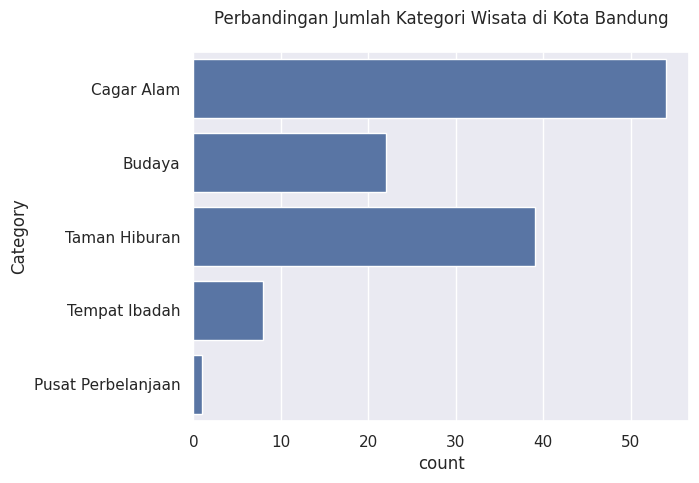

In [21]:
# Membuat visualisasi jumlah kategori wisata di Kota Bandung
sns.countplot(y='Category', data=place)
plt.title('Perbandingan Jumlah Kategori Wisata di Kota Bandung', pad=20)
plt.show()

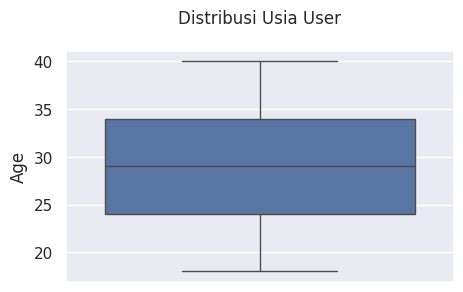

In [22]:
# Membuat visualisasi distribusi usia user
plt.figure(figsize=(5,3))
sns.boxplot(user['Age'])
plt.title('Distribusi Usia User', pad=20)
plt.show()

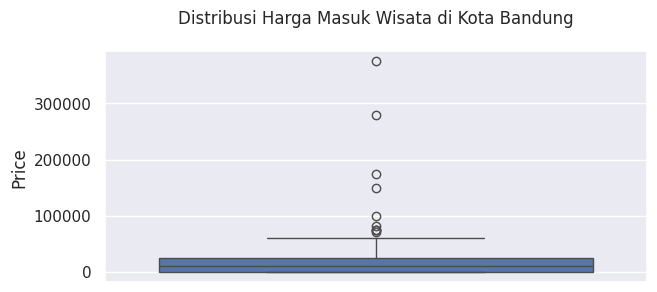

In [23]:
# Membuat visualisasi distribusi harga masuk tempat wisata
plt.figure(figsize=(7,3))
sns.boxplot(place['Price'])
plt.title('Distribusi Harga Masuk Wisata di Kota Bandung', pad=20)
plt.show()

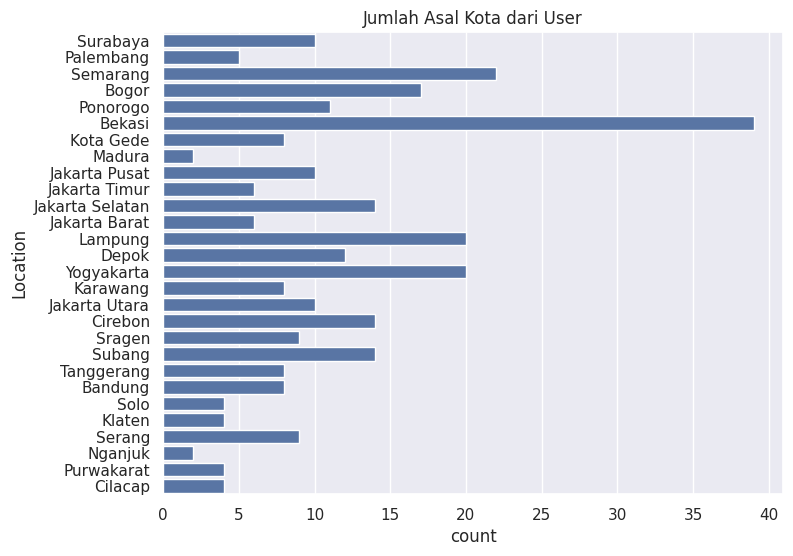

In [24]:
# Memfilter asal kota dari user
askot = user['Location'].apply(lambda x : x.split(',')[0])

# Visualisasi asal kota dari user
plt.figure(figsize=(8,6))
sns.countplot(y=askot)
plt.title('Jumlah Asal Kota dari User')
plt.show()

In [25]:
# Membaca dataset untuk dilakukan encoding
df = rating.copy()
df.head()

,User_Id,Place_Id,Place_Ratings
0,9,211,3
1,26,211,2
2,40,211,3
3,40,211,2
4,70,211,5


In [26]:
def dict_encoder(col, data=df):
    # Mengubah kolom suatu dataframe menjadi list tanpa nilai yang sama
    unique_val = data[col].unique().tolist()

    # Melakukan encoding value kolom suatu dataframe ke angka
    val_to_val_encoded = {x: i for i, x in enumerate(unique_val)}

    # Melakukan proses encoding angka ke value dari kolom suatu dataframe
    val_encoded_to_val = {i: x for i, x in enumerate(unique_val)}
    return val_to_val_encoded, val_encoded_to_val

In [27]:
# Encoding User_Id
user_to_user_encoded, user_encoded_to_user = dict_encoder('User_Id')

# Mapping User_Id ke dataframe
df['user'] = df['User_Id'].map(user_to_user_encoded)

In [28]:
# Encoding Place_Id
place_to_place_encoded, place_encoded_to_place = dict_encoder('Place_Id')

# Mapping Place_Id ke dataframe
df['place'] = df['Place_Id'].map(place_to_place_encoded)

In [29]:
# Mendapatkan jumlah user dan place
num_users, num_place = len(user_to_user_encoded), len(place_to_place_encoded)

# Mengubah rating menjadi nilai float
df['Place_Ratings'] = df['Place_Ratings'].values.astype(np.float32)

# Mendapatkan nilai minimum dan maksimum rating
min_rating, max_rating = min(df['Place_Ratings']), max(df['Place_Ratings'])

print(f'Number of User: {num_users}, Number of Place: {num_place}, Min Rating: {min_rating}, Max Rating: {max_rating}')

Number of User: 300, Number of Place: 124, Min Rating: 1.0, Max Rating: 5.0


In [30]:
# Mengacak dataset
df = df.sample(frac=1, random_state=42)
df.head(2)

,User_Id,Place_Id,Place_Ratings,user,place
415,245,228,2.0,56,17
2233,44,309,3.0,45,98


In [31]:
# Membuat variabel x untuk mencocokkan data user dan place menjadi satu value
x = df[['user', 'place']].values

# Membuat variabel y untuk membuat rating dari hasil
y = df['Place_Ratings'].apply(lambda x: (x - min_rating) / (max_rating - min_rating)).values

# Membagi menjadi 80% data train dan 20% data validasi
train_indices = int(0.8 * df.shape[0])
x_train, x_val, y_train, y_val = (
    x[:train_indices],
    x[train_indices:],
    y[:train_indices],
    y[train_indices:]
)

In [32]:
class RecommenderNet(tf.keras.Model):
    # Inisialisasi fungsi
    def __init__(self, num_users, num_places, embedding_size, **kwargs):
        super(RecommenderNet, self).__init__(**kwargs)
        self.num_users = num_users
        self.num_places = num_places
        self.embedding_size = embedding_size
        self.user_embedding = layers.Embedding( # Layer embedding user
            num_users,
            embedding_size,
            embeddings_initializer = 'he_normal',
            embeddings_regularizer = keras.regularizers.l2(1e-6)
        )
        self.user_bias = layers.Embedding(num_users, 1) # Layer embedding user bias
        self.places_embedding = layers.Embedding( # Layer embeddings places
            num_places,
            embedding_size,
            embeddings_initializer = 'he_normal',
            embeddings_regularizer = keras.regularizers.l2(1e-6)
        )
        self.places_bias = layers.Embedding(num_places, 1) # Layer embedding places bias

    def call(self, inputs):
        user_vector = self.user_embedding(inputs[:,0]) # memanggil layer embedding 1
        user_bias = self.user_bias(inputs[:, 0]) # memanggil layer embedding 2
        places_vector = self.places_embedding(inputs[:, 1]) # memanggil layer embedding 3
        places_bias = self.places_bias(inputs[:, 1]) # memanggil layer embedding 4

        dot_user_places = tf.tensordot(user_vector, places_vector, 2)

        x = dot_user_places + user_bias + places_bias

        return tf.nn.sigmoid(x) # activation sigmoid

In [33]:
model = RecommenderNet(num_users, num_place, 50) # inisialisasi model

# model compile
model.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer = keras.optimizers.Adam(learning_rate=0.0004),
    metrics=[tf.keras.metrics.RootMeanSquaredError()]
)

E0000 00:00:1778416448.509710   12063 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [34]:
class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('val_root_mean_squared_error')<0.25):
            print('Lapor! Metriks validasi sudah sesuai harapan')
            self.model.stop_training = True

In [35]:
# Memulai training
history = model.fit(
    x = x_train,
    y = y_train,
    epochs = 100,
    validation_data = (x_val, y_val),
    callbacks = [myCallback()]
)

Epoch 1/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.7139 - root_mean_squared_error: 0.3549 - val_loss: 0.7051 - val_root_mean_squared_error: 0.3436
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7113 - root_mean_squared_error: 0.3532 - val_loss: 0.7042 - val_root_mean_squared_error: 0.3430
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7134 - root_mean_squared_error: 0.3548 - val_loss: 0.7047 - val_root_mean_squared_error: 0.3433
Epoch 4/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7093 - root_mean_squared_error: 0.3521 - val_loss: 0.7048 - val_root_mean_squared_error: 0.3434
Epoch 5/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7082 - root_mean_squared_error: 0.3511 - val_loss: 0.7048 - val_root_mean_squared_error: 0.3434
Epoch 6/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7043 - root_mean_squared_error: 0.3486 - val_loss: 0.7044 - val_root_mean_squared_error: 0.3432
Epoch 7/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss

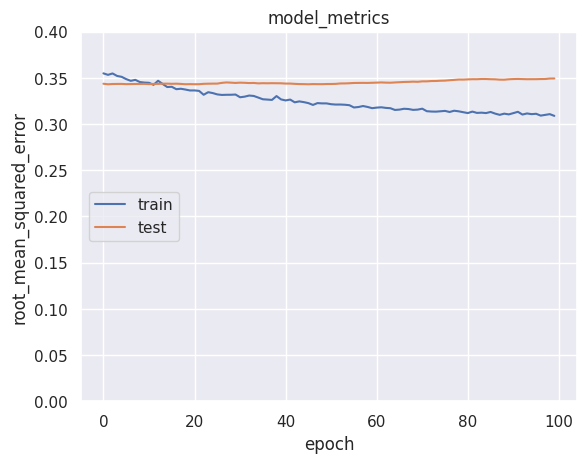

In [36]:
# Menampilkan plot loss dan validation
plt.plot(history.history['root_mean_squared_error'])
plt.plot(history.history['val_root_mean_squared_error'])
plt.title('model_metrics')
plt.ylabel('root_mean_squared_error')
plt.xlabel('epoch')
plt.ylim(ymin=0, ymax=0.4)
plt.legend(['train', 'test'], loc='center left')
plt.show()

In [37]:
# Menyiapkan dataframe
place_df = place[['Place_Id', 'Place_Name', 'Category', 'Rating', 'Price']]
place_df.columns = ['id', 'place_name', 'category', 'rating', 'price']
df = rating.copy()

In [38]:
# Mengambil sample user
# user_id = df.User_Id.sample(1).iloc[0]
user_id = 181
place_visited_by_user = df[df.User_Id == user_id]

In [39]:
# Membuat data lokasi yang belum dikunjungi user
place_not_visited = place_df[~place_df['id'].isin(place_visited_by_user.Place_Id.values)]['id']
place_not_visited = list(
    set(place_not_visited)
    .intersection(set(place_to_place_encoded.keys()))
)

place_not_visited = [[place_to_place_encoded.get(x)] for x in place_not_visited]
user_encoder = user_to_user_encoded.get(user_id)
user_place_array = np.hstack(
    ([[user_encoder]] * len(place_not_visited), place_not_visited)
)

In [40]:
# Mengambil top 7 recommendation
ratings = model.predict(user_place_array).flatten()
top_ratings_indices = ratings.argsort()[-7:][::-1]
recommended_place_ids = [
    place_encoded_to_place.get(place_not_visited[x][0]) for x in top_ratings_indices
]

print('Daftar rekomendasi untuk: {}'.format('User ' + str(user_id)))
print('===' * 15, '\n')
print('----' * 15)
print('Tempat dengan rating wisata paling tinggi dari user')
print('----' * 15)

top_place_user = (
    place_visited_by_user.sort_values(
        by = 'Place_Ratings',
        ascending=False
    )
    .head(5)
    .Place_Id.values
)

place_df_rows = place_df[place_df['id'].isin(top_place_user)]
for row in place_df_rows.itertuples():
    print(row.place_name, ':', row.category)

print('')
print('----' * 15)
print('Top 7 place recommendation')
print('----' * 15)

recommended_place = place_df[place_df['id'].isin(recommended_place_ids)]
for row, i in zip(recommended_place.itertuples(), range(1, 8)):
    print(i, '.', row.place_name, '\n', ' ', row.category, ',', 'Harga Tiket Masuk', ',', row.price, ',', 'Rating Wisata', row.rating)

print('==='*15)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Daftar rekomendasi untuk: User 181

------------------------------------------------------------
Tempat dengan rating wisata paling tinggi dari user
------------------------------------------------------------
Taman Balai Kota Bandung : Taman Hiburan
Gunung Manglayang : Cagar Alam
Kampung Batu Malakasari : Taman Hiburan
Batununggal Indah Club : Taman Hiburan
The Lodge Maribaya : Cagar Alam

------------------------------------------------------------
Top 7 place recommendation
------------------------------------------------------------
1 . Selasar Sunaryo Art Space 
   Taman Hiburan , Harga Tiket Masuk , 25000 , Rating Wisata 4.6
2 . Teras Cikapundung BBWS 
   Taman Hiburan , Harga Tiket Masuk , 0 , Rating Wisata 4.3
3 . Museum Pos Indonesia 
   Budaya , Harga Tiket Masuk , 0 , Rating Wisata 4.5
4 . Masjid Agung Trans Studio Bandung 
   Tempat Ibadah , Harga Tiket Masuk , 0 , Rating Wisata 4.8
5 . Sanghyang Heuleut 
   Cagar Alam , Harga Tiket Mas